# EDA
Primero descargamos los datos del kaggle y los guardamos en la carpeta data/raw con kagglehub

In [2]:
import kagglehub
kagglehub.login()

In [12]:
import os
import shutil

data_raw_path = os.path.join('..','data', 'raw')
os.makedirs(data_raw_path, exist_ok=True)
COMPETITION_NAME = 'store-sales-time-series-forecasting'

In [ ]:

path = kagglehub.competition_download(COMPETITION_NAME)

# Mover los archivos descargados a la carpeta data/raw

shutil.move(path, data_raw_path)

print('Archivos descargados y movidos a la carpeta:' , data_raw_path)

100%|██████████| 21.4M/21.4M [00:05<00:00, 4.25MB/s]

Extracting files...


Error: Destination path '..\data\raw\store-sales-time-series-forecasting' already exists

### Empezaremos a ver los datos train y los test en el time series con respecto al tiempo y las ventas

In [10]:
os.path.join(data_raw_path, 'train.csv')

'..\\data\\raw\\train.csv'

In [18]:
#Importamos el train y test
import pandas as pd
train = pd.read_csv(os.path.join(data_raw_path, COMPETITION_NAME, 'train.csv'), index_col='id', parse_dates=['date'])
test = pd.read_csv(os.path.join(data_raw_path, COMPETITION_NAME, 'test.csv'), index_col='id', parse_dates=['date'])

In [19]:
test.head()


,date,store_nbr,family,onpromotion
id,,,,
3000888,2017-08-16,1,AUTOMOTIVE,0
3000889,2017-08-16,1,BABY CARE,0
3000890,2017-08-16,1,BEAUTY,2
3000891,2017-08-16,1,BEVERAGES,20
3000892,2017-08-16,1,BOOKS,0


In [17]:
test.columns

Index(['date', 'store_nbr', 'family', 'onpromotion'], dtype='object')

In [20]:
#Pasamos la columna date a index para poder hacer un plot de series temporales
train_index_date = train.reset_index().set_index('date')
train_index_date.head()

,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,0,1,AUTOMOTIVE,0.0,0
2013-01-01,1,1,BABY CARE,0.0,0
2013-01-01,2,1,BEAUTY,0.0,0
2013-01-01,3,1,BEVERAGES,0.0,0
2013-01-01,4,1,BOOKS,0.0,0


In [34]:
#Como tiene dias duplicados vamos a agrupar por fecha y sumar las ventas de cada dia
train_index_date = train_index_date.groupby('date').sum()
train_index_date.head()

,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,1586871,49005,AUTOMOTIVEBABY CAREBEAUTYBEVERAGESBOOKSBREAD/B...,2511.618999,0
2013-01-02,4762395,49005,AUTOMOTIVEBABY CAREBEAUTYBEVERAGESBOOKSBREAD/B...,496092.417944,0
2013-01-03,7937919,49005,AUTOMOTIVEBABY CAREBEAUTYBEVERAGESBOOKSBREAD/B...,361461.231124,0
2013-01-04,11113443,49005,AUTOMOTIVEBABY CAREBEAUTYBEVERAGESBOOKSBREAD/B...,354459.677093,0
2013-01-05,14288967,49005,AUTOMOTIVEBABY CAREBEAUTYBEVERAGESBOOKSBREAD/B...,477350.121229,0


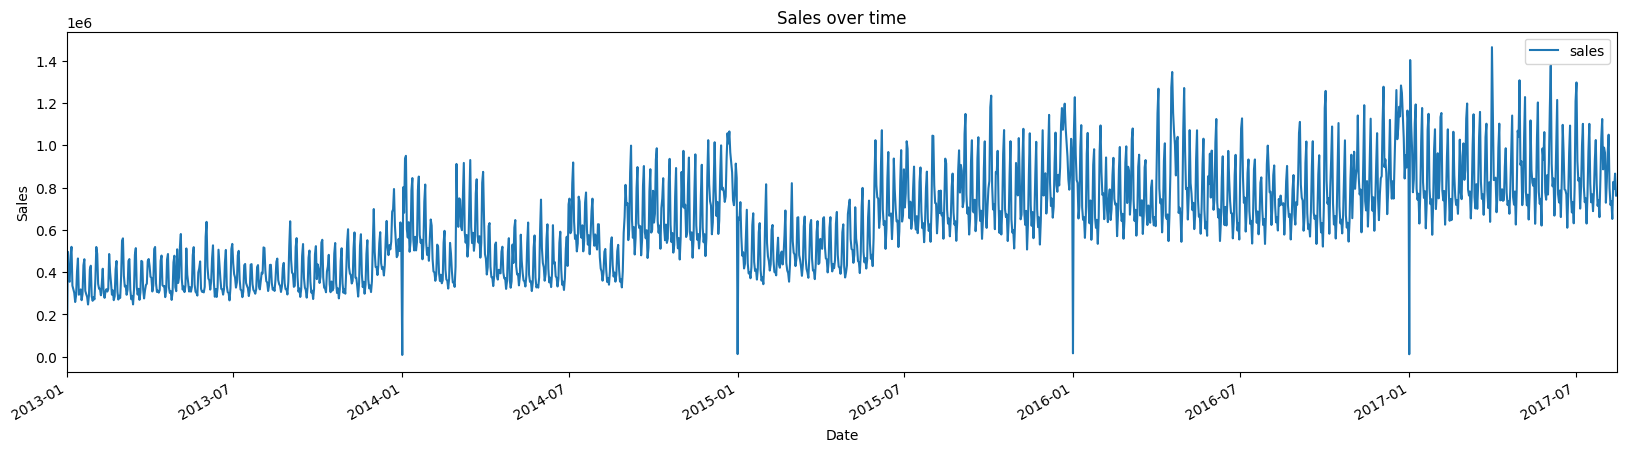

In [35]:
#Hacemos el plot y ponemos de x el indice date
import matplotlib.pyplot as plt

train_index_date.plot( y='sales', figsize=(20, 5))
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales over time')
plt.xlim(train_index_date.index.min(), train_index_date.index.max())
plt.show()


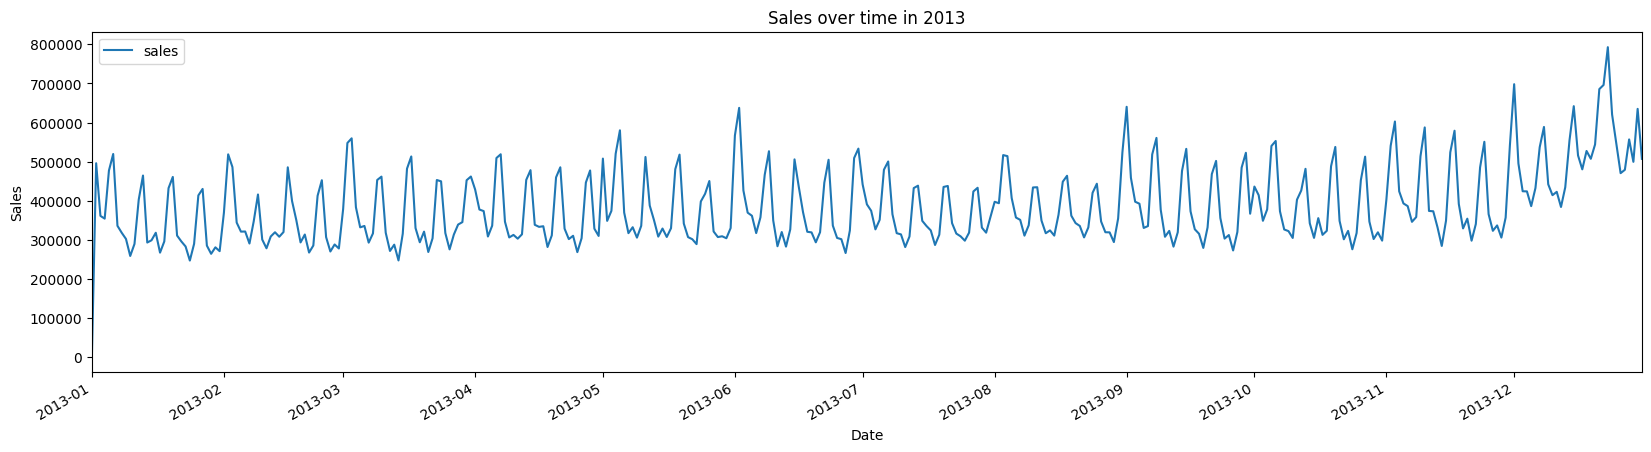

In [36]:
#Como no se ve bien solo pondre un año el 2013 para probar
train_2013 = train_index_date[train_index_date.index.year == 2013]
train_2013.plot(  kind='line',y='sales', figsize=(20, 5))
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales over time in 2013')
plt.xlim(train_2013.index.min(), train_2013.index.max())
plt.show()

<Axes: title={'center': 'Sales over time in December 2013'}, xlabel='Date', ylabel='Sales'>

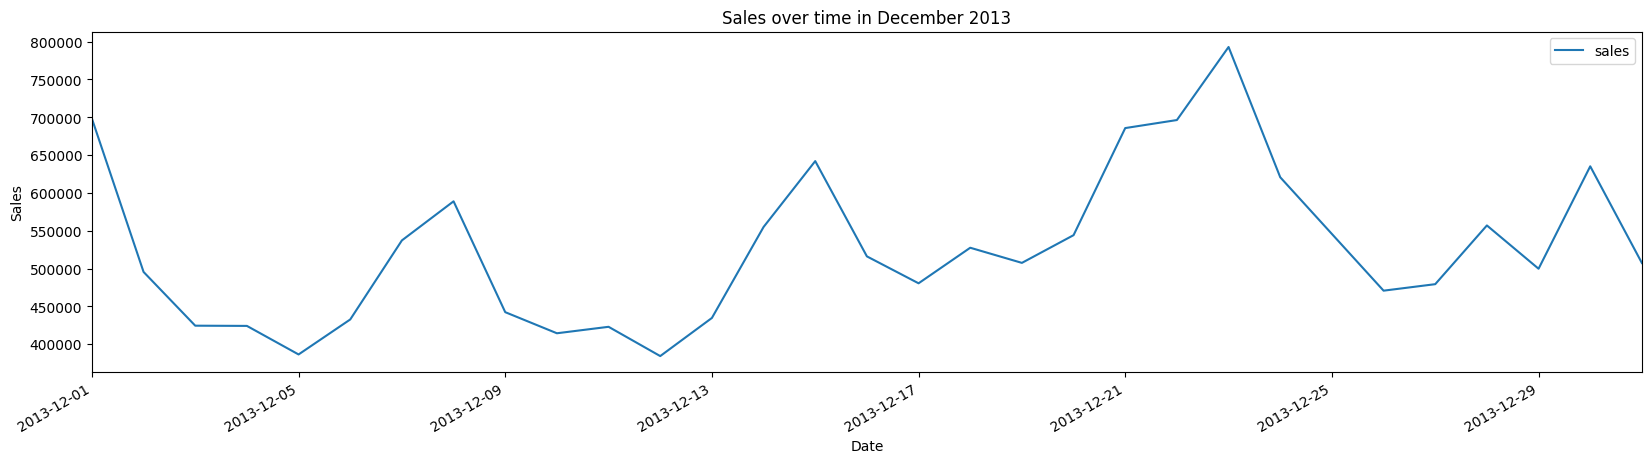

In [37]:
train_2013_december = train_2013[train_2013.index.month == 12]
train_2013_december.plot(  kind='line',y='sales', figsize=(20, 5),
                        xlabel='Date', ylabel='Sales', title='Sales over time in December 2013',
                        xlim=(train_2013_december.index.min(), train_2013_december.index.max()))

### Estos son los datos de train y test si juntamos los sales, vamos a ver ahora los datos de sales para cada tipo de familia

In [44]:
train['family'].value_counts().index

Index(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS',
       'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD'],
      dtype='object', name='family')

In [43]:
#Longitud de tipos de familia
train['family'].value_counts().index.shape

(33,)

Hay 33 tipos de familia en el dataset vamos a ver algunas con un plot de prueba

In [77]:
train_index_date = train.reset_index().set_index('date')
train_automotive = train_index_date[train_index_date['family'] == 'AUTOMOTIVE']
train_automotive = train_automotive.groupby('date').sum()
train_bread = train_index_date[train_index_date['family'] == 'BREAD/BAKERY']
train_bread = train_bread.groupby('date').sum()
train_dairy = train_index_date[train_index_date['family'] == 'DAIRY']
train_dairy = train_dairy.groupby('date').sum()

In [ ]:
train_automotive.head()
#No hacemos caso a la columna family

,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,47223,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,0.0,0
2013-01-02,143451,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,255.0,0
2013-01-03,239679,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,161.0,0
2013-01-04,335907,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,169.0,0
2013-01-05,432135,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,342.0,0


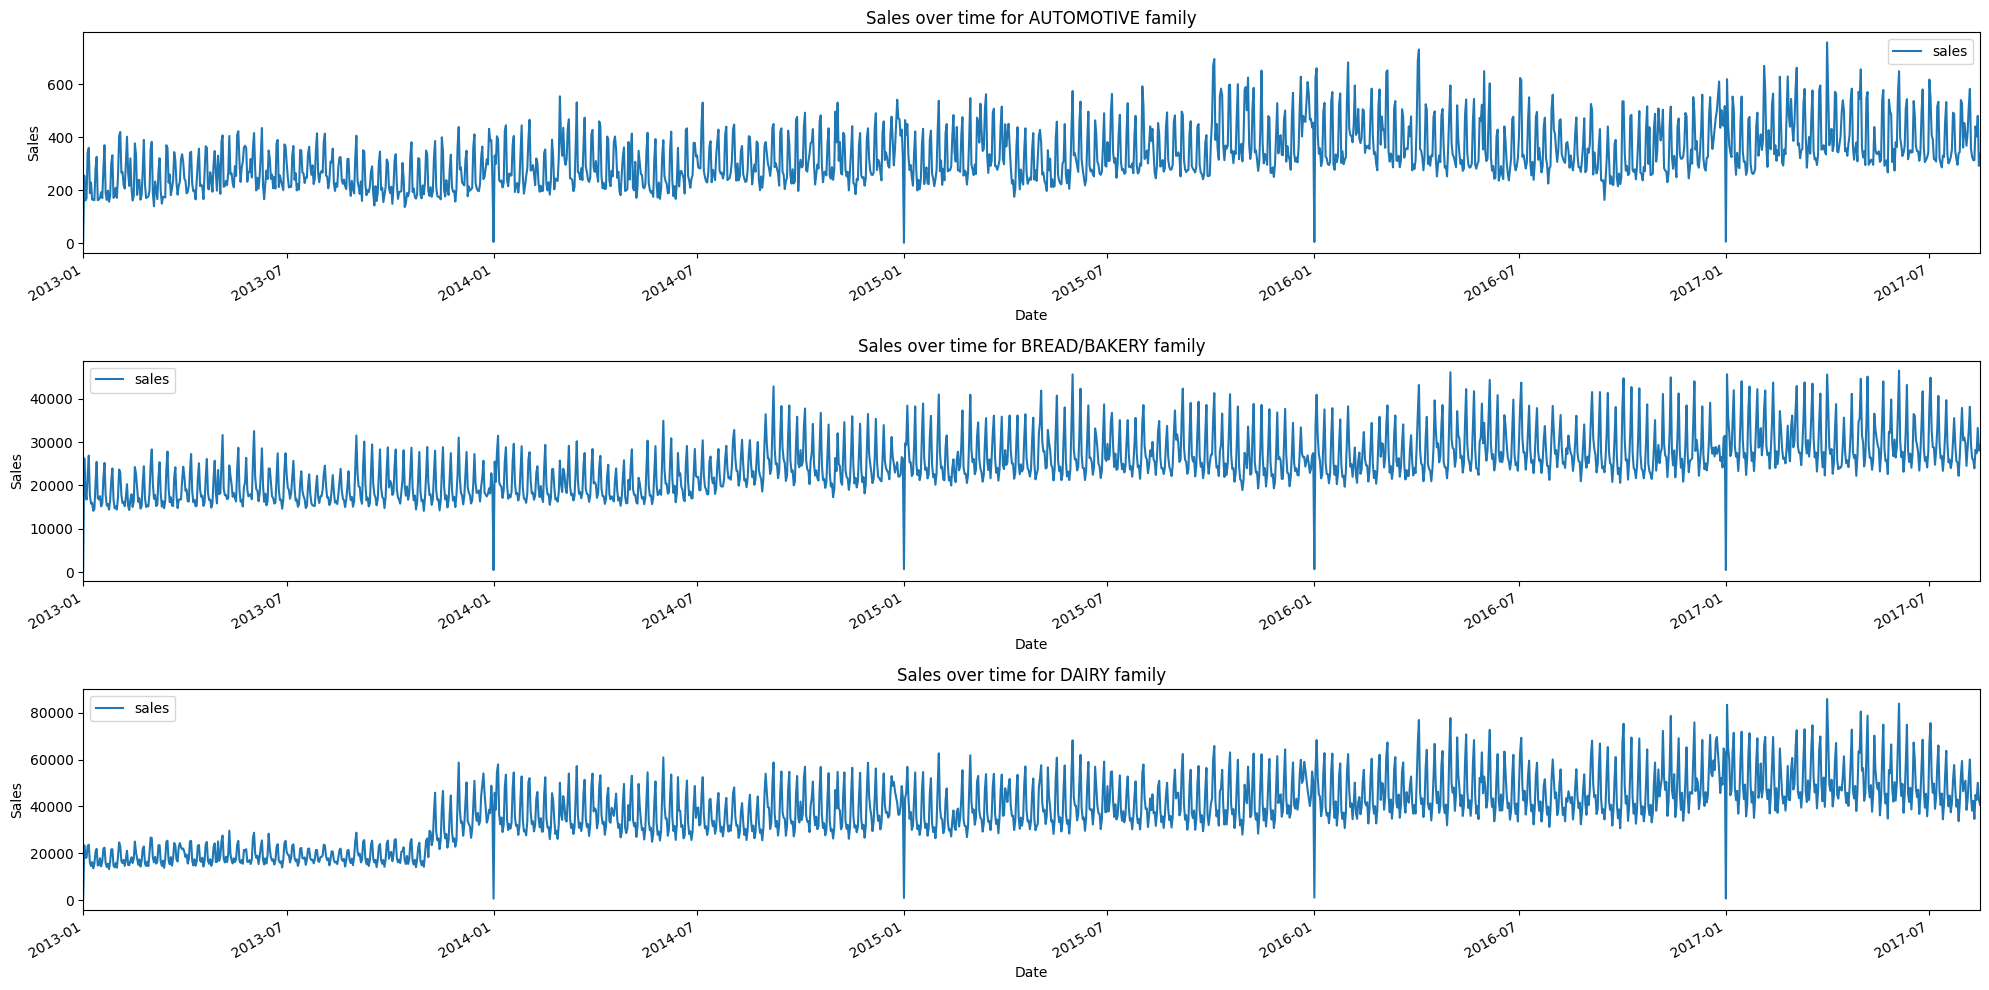

In [79]:

fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot(311)
train_automotive.plot(y='sales', ax=ax1)
ax1.set_title('Sales over time for AUTOMOTIVE family')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales')
ax1.set_xlim(train_automotive.index.min(), train_automotive.index.max())

ax2 = fig.add_subplot(312)
train_bread.plot(y='sales', ax=ax2)
ax2.set_title('Sales over time for BREAD/BAKERY family')
ax2.set_xlabel('Date')
ax2.set_ylabel('Sales')
ax2.set_xlim(train_bread.index.min(), train_bread.index.max())

ax3 = fig.add_subplot(313)
train_dairy.plot(y='sales', ax=ax3)
ax3.set_title('Sales over time for DAIRY family')
ax3.set_xlabel('Date')
ax3.set_ylabel('Sales')
ax3.set_xlim(train_dairy.index.min(), train_dairy.index.max())

plt.tight_layout()
plt.show()

In [80]:
#Ahora solo en 2016
train_automotive_2016 = train_automotive[train_automotive.index.year == 2016]
train_bread_2016 = train_bread[train_bread.index.year == 2016]
train_dairy_2016 = train_dairy[train_dairy.index.year == 2016]

In [81]:
train_automotive_2016.head()

,id,store_nbr,family,sales,onpromotion
date,,,,,
2016-01-01,105128199,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,4.0,0
2016-01-02,105224427,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,625.0,0
2016-01-03,105320655,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,661.0,0
2016-01-04,105416883,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,407.0,9
2016-01-05,105513111,1485,AUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMOTIVEAUTOMO...,338.0,2


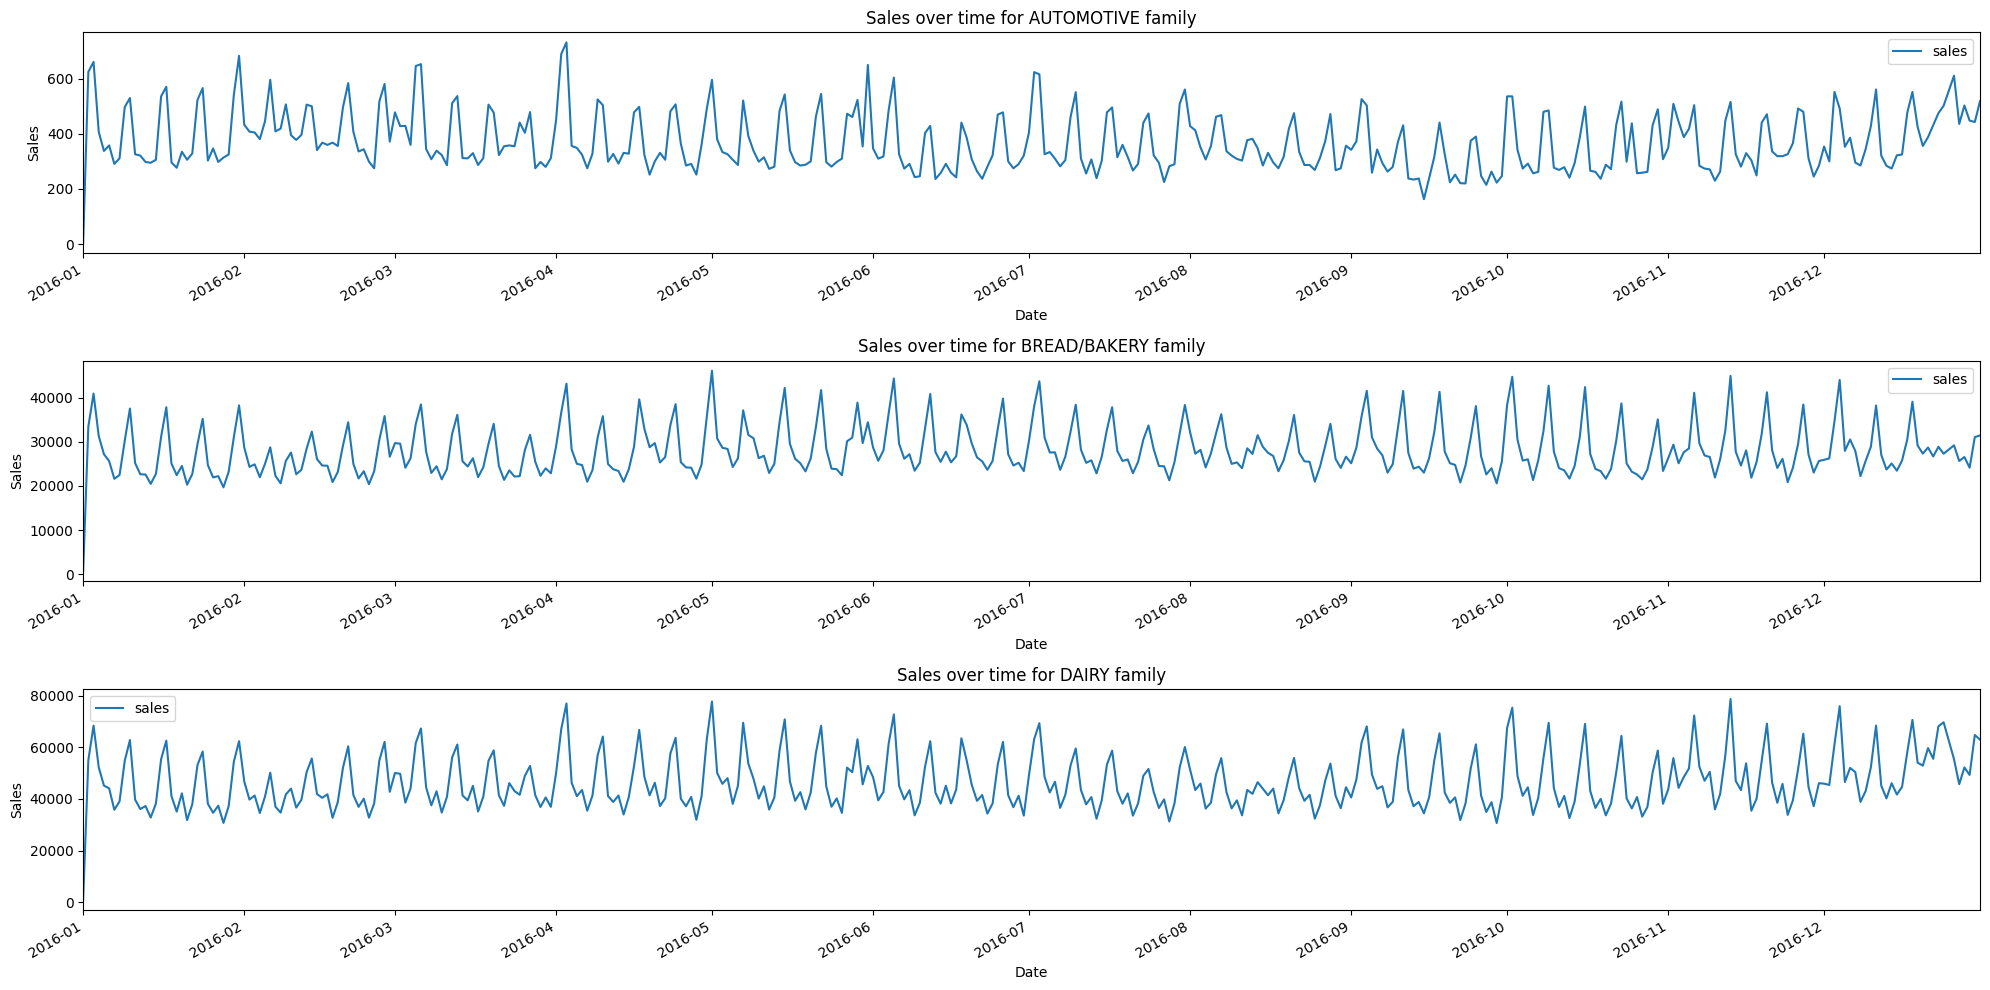

In [82]:

fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot(311)
train_automotive_2016.plot(y='sales', ax=ax1)
ax1.set_title('Sales over time for AUTOMOTIVE family')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales')
ax1.set_xlim(train_automotive_2016.index.min(), train_automotive_2016.index.max())

ax2 = fig.add_subplot(312)
train_bread_2016.plot(y='sales', ax=ax2)
ax2.set_title('Sales over time for BREAD/BAKERY family')
ax2.set_xlabel('Date')
ax2.set_ylabel('Sales')
ax2.set_xlim(train_bread_2016.index.min(), train_bread_2016.index.max())

ax3 = fig.add_subplot(313)
train_dairy_2016.plot(y='sales', ax=ax3)
ax3.set_title('Sales over time for DAIRY family')
ax3.set_xlabel('Date')
ax3.set_ylabel('Sales')
ax3.set_xlim(train_dairy_2016.index.min(), train_dairy_2016.index.max())

plt.tight_layout()
plt.show()

Cada uno tiene sus ventas y sus ventas en cada tienda